In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/kaggle/input/datasets/bhanupratapbiswas/customer-behavior-analysis/ecommerce_customer_data_custom_ratios.csv")

df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [3]:
print("Shape:", df.shape)

print("Info:", df.info())

print(df.describe())

print(df.isnull().sum())

Shape: (250000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB
Info: None


In [4]:
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

print("New shape:", df.shape)

Duplicates: 0
New shape: (250000, 13)


In [5]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

In [6]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

print(df['Purchase Date'].min())
print(df['Purchase Date'].max())

2020-01-01 00:15:00
2023-09-15 12:24:08


In [7]:
df['Year'] = df['Purchase Date'].dt.year
df['Month'] = df['Purchase Date'].dt.month
df['Month_Name'] = df['Purchase Date'].dt.month_name()

In [8]:
total_customers = df['Customer ID'].nunique()
total_transactions = df.shape[0]
total_revenue = df['Total Purchase Amount'].sum()
average_purchase = df['Total Purchase Amount'].mean()

print("Total Customers:", total_customers)
print("Total Transactions:", total_transactions)
print("Total Revenue:", total_revenue)
print("Average Purchase Amount:", round(average_purchase, 2))

Total Customers: 49673
Total Transactions: 250000
Total Revenue: 681342683
Average Purchase Amount: 2725.37


In [9]:
analysis_date = df['Purchase Date'].max() + pd.Timedelta(days=1)

In [10]:
rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (analysis_date - x.max()).days,
    'Customer ID': 'count',
    'Total Purchase Amount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
1,58,1,3491
2,299,3,7988
3,89,8,22587
4,127,4,8715
5,171,8,12524


In [11]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'].rank(method='first'),
    4,
    labels=[4, 3, 2, 1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1, 2, 3, 4]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    4,
    labels=[1, 2, 3, 4]
)

In [12]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(int) +
    rfm['F_Score'].astype(int) +
    rfm['M_Score'].astype(int)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
1,58,1,3491,4,1,1,6
2,299,3,7988,2,1,1,4
3,89,8,22587,3,4,4,11
4,127,4,8715,3,2,1,6
5,171,8,12524,3,4,2,9


In [13]:
def segment_customer(score):
    if score >= 10:
        return 'High Value'
    elif score >= 7:
        return 'Loyal'
    elif score >= 5:
        return 'Potential'
    else:
        return 'At Risk'

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
1,58,1,3491,4,1,1,6,Potential
2,299,3,7988,2,1,1,4,At Risk
3,89,8,22587,3,4,4,11,High Value
4,127,4,8715,3,2,1,6,Potential
5,171,8,12524,3,4,2,9,Loyal


Segment
Loyal         17050
High Value    13769
Potential     10215
At Risk        8639
Name: count, dtype: int64


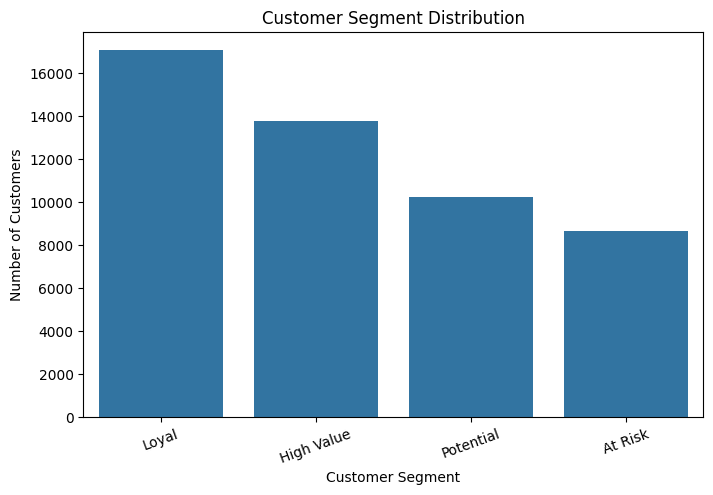

In [14]:
segment_counts = rfm['Segment'].value_counts()

print(segment_counts)

plt.figure(figsize=(8,5))
sns.countplot(data=rfm, x='Segment', order=segment_counts.index)
plt.title('Customer Segment Distribution')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)
plt.show()

In [15]:
segment_profile = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

segment_profile

,Recency,Frequency,Monetary
Segment,,,
At Risk,584.83,2.38,5896.11
High Value,100.41,7.54,21390.96
Loyal,204.66,5.20,14116.25
Potential,299.70,3.62,9318.85


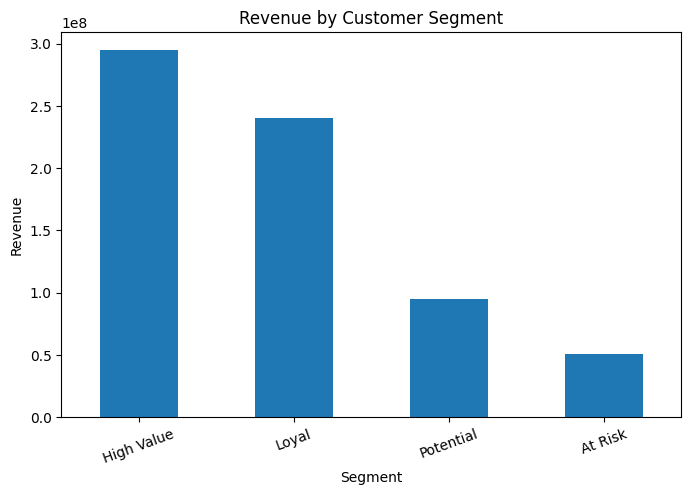

In [16]:
revenue_segment = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
revenue_segment.plot(kind='bar')
plt.title('Revenue by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Revenue')
plt.xticks(rotation=20)
plt.show()

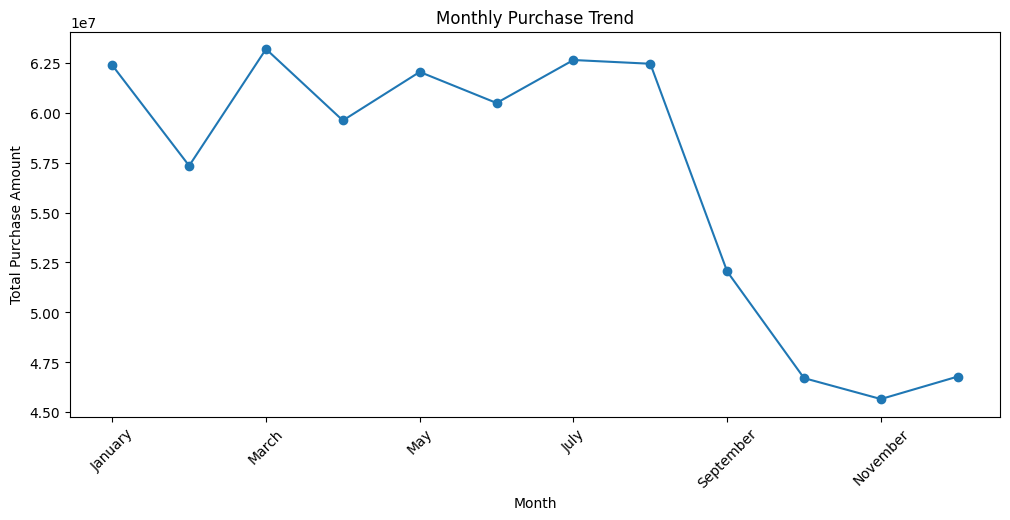

In [17]:
monthly_sales = df.groupby('Month_Name')['Total Purchase Amount'].sum()

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(12,5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Purchase Trend')
plt.xlabel('Month')
plt.ylabel('Total Purchase Amount')
plt.xticks(rotation=45)
plt.show()

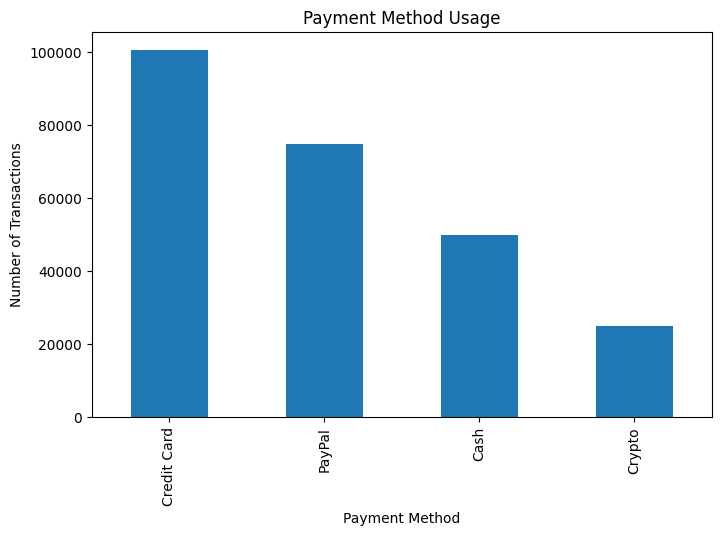

In [18]:
payment = df['Payment Method'].value_counts()

plt.figure(figsize=(8,5))
payment.plot(kind='bar')
plt.title('Payment Method Usage')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.show()

In [19]:
at_risk = rfm[rfm['Segment'] == 'At Risk']

print("Potential At-Risk Customers:", len(at_risk))
at_risk.head(10)

Potential At-Risk Customers: 8639


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
2,299,3,7988,2,1,1,4,At Risk
7,566,3,7835,1,1,1,3,At Risk
34,972,2,3345,1,1,1,3,At Risk
40,479,2,5188,1,1,1,3,At Risk
49,632,4,8325,1,2,1,4,At Risk
52,449,2,5280,1,1,1,3,At Risk
53,300,2,4833,2,1,1,4,At Risk
57,508,3,6606,1,1,1,3,At Risk
63,702,2,1630,1,1,1,3,At Risk


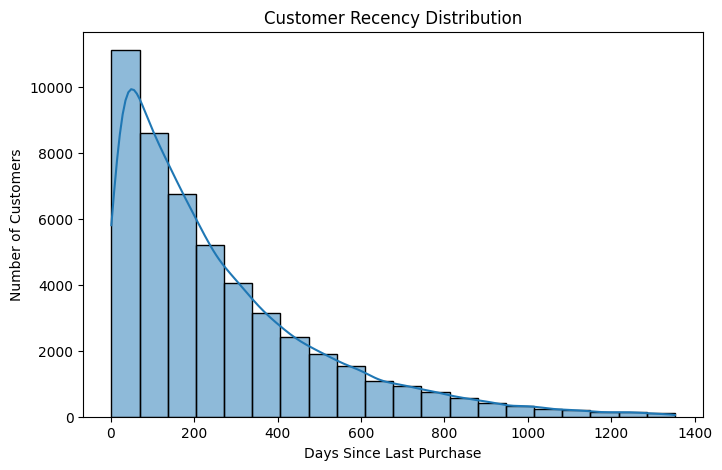

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(rfm['Recency'], bins=20, kde=True)
plt.title('Customer Recency Distribution')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Number of Customers')
plt.show()

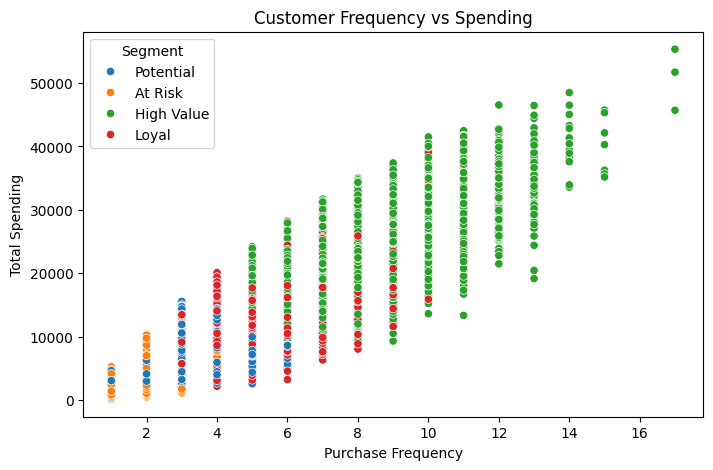

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Segment'
)

plt.title('Customer Frequency vs Spending')
plt.xlabel('Purchase Frequency')
plt.ylabel('Total Spending')
plt.show()

In [22]:
summary = rfm.groupby('Segment').agg(
    Customers=('Segment', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(2)

summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
At Risk,8639,584.83,2.38,5896.11
High Value,13769,100.41,7.54,21390.96
Loyal,17050,204.66,5.20,14116.25
Potential,10215,299.70,3.62,9318.85


## Recommendations

1. Reward High Value customers with loyalty benefits and exclusive offers.

2. Encourage Loyal customers to maintain repeat purchases through personalized promotions.

3. Target Potential customers with product recommendations and limited-time offers.

4. Run reactivation campaigns for At Risk customers using discounts, reminders, and personalized messages.

5. Use customer purchase history and category preferences to create targeted marketing campaigns.